# Домашнее задание 3. Сверточные нейронные сети (CNN)

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1–4 | 3 (0.75 за задачу) |
| **Средние** | 5–7 | 3 (1 за задачу) |
| **Сложные** | 8–9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)  # заметил, что данного параметра не достаточно
torch.cuda.manual_seed(SEED)  # нужно устанавливать еще этот параметр, поскольку я выполняю вычисления на CUDA
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cuda


---

## Теоретический минимум

### Почему для изображений нужны специальные архитектуры

Полносвязные сети (MLP) не учитывают пространственную структуру данных.
Для изображения размером $H \times W \times C$ полносвязный слой требует
$H \cdot W \cdot C \cdot N_{out}$ параметров, это быстро становится неуправляемым.

CNN используют три ключевые идеи:
- **Локальные связи**: каждый нейрон связан только с небольшой областью входа.
- **Разделение параметров** (parameter sharing): одно ядро применяется ко всем позициям.
- **Эквивариантность к сдвигу**: сдвиг входа приводит к аналогичному сдвигу карты признаков.

### Операция свертки

Дискретная двумерная свертка с ядром размера $K \times K$:

$$(f * g)(i, j) = \sum_{m=0}^{K-1}\sum_{n=0}^{K-1} f(m,n)\,g(i+m,\,j+n)$$

Результат — **карта признаков** (feature map).

### Формула размера выхода

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

где $H_{in}$ — высота входного изображения, $K$ — размер ядра (фильтра), $S$ — stride (шаг перемещения ядра), $P$ — padding (добавление нулевых границ).

### Padding

- **valid** ($P=0$): размер уменьшается при каждой свертке.
- **same** ($P = \lfloor K/2 \rfloor$ при $S=1$): размер сохраняется.

### Stride

Шаг $S > 1$ уменьшает пространственное разрешение — альтернатива pooling.

### Pooling

- **Max Pooling** — берет максимум в окне (выделяет наиболее активный признак).
- **Average Pooling** — среднее в окне (сглаживает).

Pooling уменьшает разрешение и дает **локальную инвариантность** к малым сдвигам.

### Каналы и число параметров

Для свертки с $C_{in}$ входных и $C_{out}$ выходных каналов, ядром $K \times K$:

$$N_{params} = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$$

### Receptive field

Рецептивное поле — область входного изображения, влияющая на один элемент
выходной карты признаков. Растет с глубиной сети.

### Эквивариантность и инвариантность

- **Эквивариантность к сдвигу**: свертка гарантирует, что сдвиг входа порождает
  такой же сдвиг карты признаков.
- **Инвариантность**: достигается через pooling и глобальное усреднение.

### Задачи компьютерного зрения

| Задача | Вход | Выход |
|--------|------|-------|
| Классификация | Изображение | Метка класса |
| Детекция | Изображение | Bounding boxes + классы |
| Сегментация | Изображение | Маска (класс для каждого пикселя) |


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание базовых элементов CNN: свертка, padding, stride, pooling, подсчет параметров.

## Задача 1. Формула размера выхода свертки

### Постановка задачи

Реализуйте функцию, вычисляющую размер выхода сверточного/pooling слоя,
и проверьте ее на нескольких тестовых случаях.

**Формула:**
$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

**Формула из документации:**
$$H_{m} = \left\lfloor \frac{H + 2 \cdot padding[0] - 1 \cdot (kernel\_size[0] - 1) - 1}{stride[0]} + 1\right\rfloor$$
$$W_{m} = \left\lfloor \frac{W + 2 \cdot padding[1] - 1 \cdot (kernel\_size[1] - 1) - 1}{stride[1]} + 1\right\rfloor$$

### Задача
1. Реализуйте `conv_output_size(h_in, k, p, s)`.
2. Проверьте на 5 случаях: (32,3,0,1), (32,3,1,1), (32,5,0,2), (28,3,1,2), (224,7,3,2).
3. Реализуйте `pool_output_size` (по умолчанию stride = kernel_size).
4. Сверьте с `nn.Conv2d` / `nn.MaxPool2d`.


In [ ]:
# Задача 1. Формула размера выхода свертки

def conv_output_size(h_in, k, p=0, s=1):
    """
    Вычисляет размер H_out карты признаков после свёртки.
    Параметры:
        h_in - высота H
        k - kernel_size 
        p - padding
        s - stride
    """
    if not (h_in > 0):
        raise ValueError("h_in must be > 0")
    if not (k > 0):
        raise ValueError("k must be > 0")
    if not (p >= 0):
        raise ValueError("p must be >= 0")
    if not (s >= 1):
        raise ValueError("s must be >= 1")
    return int(
        np.floor((h_in + 2 * p - k) / s) + 1
    )

def pool_output_size(h_in, k, p=0, s=None):
    """
    Вычисляет размер H_out pooling
    Параметры:
        h_in - высота H
        k - kernel size
        p - padding (игнорируется и равен 0)
        s - stride, по умолчанию == k
    """
    if not (h_in > 0):
        raise ValueError("h_in must be > 0")
    if not (k > 0):
        raise ValueError("k must be > 0")
    if not (p >= 0):
        raise ValueError("p must be >= 0")
    if s is None:
        s = k
    elif not (s >= 1):
        raise ValueError("s must be >= 1")
    return conv_output_size(h_in=h_in, k=k, p=0, s=s)

# вы можете написать свою архитектуру эксперимента
# --- Тестовые случаи ---
#              H    k  p  s
conv_cases = [(32,  3, 0, 1),
              (32,  3, 1, 1),
              (32,  5, 0, 2),
              (28,  3, 1, 2),
              (224, 7, 3, 2),]

# --- Сверка с PyTorch ---
print()  # \n в строке подсвечивается у меня как ошибка, поэтому для переноса ставлю пустые print
print("Сверка с PyTorch nn.Conv2d:")
print("-" * 65)

# Conv
for i, (h, k, p, s) in enumerate(conv_cases, 1):
    # Создаём Свёрточный слой
    conv = nn.Conv2d(3, 16, kernel_size=k, stride=s, padding=p, bias=False)

    # Проверяем на случайном тензоре
    x = torch.randn(1, 3, h, h)
    y = conv(x)
    # y.shape[0] — размер батча (batch)
    # y.shape[1] — количество каналов
    # y.shape[2] — высота выхода карты признаков
    # y.shape[3] — ширина выхода карты признаков
    h_out = y.shape[2]
    exp = conv_output_size(h, k, p, s)

    # Сверка с результатом моей функции
    assert h_out == exp, f"Conv case {i}: PyTorch gave {h_out}, expected {exp}"
    print(f"case {i}: h_in={h:3d} -> h_out={h_out:3d} (OK)")

print("\nСверка с PyTorch nn.MaxPool2d:")
print("-" * 65)

# Pooling
print("Размер после MaxPool2d(2):")
for i, h in enumerate([32, 28, 14, 7], 1):
    k = 2    # kernel_size
    pool = nn.MaxPool2d(kernel_size=k)
    
    # Проверяем на случайном тензоре
    x = torch.randn(1, 3, h, h)
    y = pool(x)

    h_out = y.shape[2]
    exp = pool_output_size(h, k, p)
    
    # Сверка с результатом моей функции
    assert h_out == exp, f"Pool case {i}: PyTorch gave {h_out}, expected {exp}"
    print(f"case {i}: h_in={h:3d} -> h_out={h_out:3d} (OK)")

print()
print("Все проверки пройдены.")


Сверка с PyTorch nn.Conv2d:
-----------------------------------------------------------------
case 1: h_in= 32 -> h_out= 30 (OK)
case 2: h_in= 32 -> h_out= 32 (OK)
case 3: h_in= 32 -> h_out= 14 (OK)
case 4: h_in= 28 -> h_out= 14 (OK)
case 5: h_in=224 -> h_out=112 (OK)

Сверка с PyTorch nn.MaxPool2d:
-----------------------------------------------------------------
Размер после MaxPool2d(2):
case 1: h_in= 32 -> h_out= 16 (OK)
case 2: h_in= 28 -> h_out= 14 (OK)
case 3: h_in= 14 -> h_out=  7 (OK)
case 4: h_in=  7 -> h_out=  3 (OK)

Все проверки пройдены.


---

## Задача 2. Подсчет параметров свертки

### Постановка задачи

Сравните число параметров сверточного и полносвязного слоев при одинаковых
входных/выходных размерностях.

**Формулы:**
- Conv: $N = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$
- FC: $N = N_{in} \cdot N_{out} + N_{out}$

### Задача
1. Реализуйте `count_conv_params` и `count_fc_params`.
2. Сравните для входа 32x32x3 с выходом 32x32x16.
3. Покажите преимущество parameter sharing.


In [3]:
# Задача 2. Подсчет параметров свертки

def count_conv_params(c_in, c_out, k, bias=True):
    """
    Число параметров Conv2d.
    Параметры:
        c_in - количество входных каналов (для RGB-изображения = 3)
        c_out - количество выходных каналов(фильтров)
        k - размер ядра свертки (предполагается квадратное ядро, 3, 5, 7 и т.д.)
        bias - смещение: если True, добавляется обучаемый параметр
               смещения для каждого выходного канала
    """
    return k ** 2 * c_in * c_out + (c_out if bias else 0)

def count_fc_params(n_in, n_out, bias=True):
    """
    Число параметров Linear.
    Параметры:
        n_in - количество входных признаков для полносвязного слоя
        n_out - количество выходных признаков
        bias - смещение: если True, добавляется обучаемый параметр
               смещения для каждого выходного канала
    """
    return n_in * n_out + (n_out if bias else 0)

# --- Сравнение ---
# Вход: 32x32, 3 канала.  Выход: 32x32, 16 каналов.

conv_p = count_conv_params(3, 16, 3)
fc_p   = count_fc_params(32 * 32 * 3, 32 * 32 * 16)

print("Сравнение числа параметров:")
print("-" * 65)
print(f"  Conv2d(3, 16, kernel_size=3): {conv_p:>12,}")
print(f"  Linear(3072, 16384):          {fc_p:>12,}")
print(f"  Отношение FC / Conv:          {fc_p / conv_p:>12,.0f}x")

# Верификация через PyTorch
conv = nn.Conv2d(3, 16, kernel_size=3, bias=True)
fc   = nn.Linear(32 * 32 * 3, 32 * 32 * 16, bias=True)

conv_actual = sum(p.numel() for p in conv.parameters())
fc_actual   = sum(p.numel() for p in fc.parameters())

print()
print("Проверка через PyTorch:")
print(f"  Conv2d параметры: {conv_actual:>12,}  (расчёт: {conv_p})")
print(f"  Linear параметры: {fc_actual:>12,}  (расчёт: {fc_p})")

print()
print("Вывод: свертка с ядром 3x3 требует на несколько порядков\n" +
      "меньше параметров благодаря разделению весов (parameter sharing).")

Сравнение числа параметров:
-----------------------------------------------------------------
  Conv2d(3, 16, kernel_size=3):          448
  Linear(3072, 16384):            50,348,032
  Отношение FC / Conv:               112,384x

Проверка через PyTorch:
  Conv2d параметры:          448  (расчёт: 448)
  Linear параметры:   50,348,032  (расчёт: 50348032)

Вывод: свертка с ядром 3x3 требует на несколько порядков
меньше параметров благодаря разделению весов (parameter sharing).


---

## Задача 3. CNN и отслеживание размерностей

### Постановка задачи

Постройте CNN для входа 1x28x28 (MNIST) и пропустите через нее случайный тензор,
выводя размерность на каждом слое.

### Архитектура
```
Input(1, 28, 28)
  -> Conv2d(1, 16, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Conv2d(16, 32, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Flatten
  -> Linear(32*7*7, 10)
```

### Задача
1. Реализуйте модель с печатью shape в forward.
2. Пропустите батч (4, 1, 28, 28) и проверьте размерности.
3. Выведите общее число параметров.


In [4]:
# Задача 3. CNN и отслеживание размерностей

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x, verbose=False):
        if verbose:
            print(f"  Input:              {x.shape}")
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        if verbose:
            print(f"  Conv1 + ReLU + Pool: {x.shape}")
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        if verbose:
            print(f"  Conv2 + ReLU + Pool: {x.shape}")
        x = x.view(x.size(0), -1)

        if verbose:
            print(f"  Flatten:            {x.shape}")
        x = self.fc(x)

        if verbose:
            print(f"  FC (output):        {x.shape}")
        return x


model = SimpleCNN()
x = torch.randn(4, 1, 28, 28)

print("Прохождение тензора через сеть:")
out = model(x, verbose=True)

total_params = sum(
    p.numel() for p in model.parameters()
)
print()
print(f"Общее число параметров: {total_params:,}")

Прохождение тензора через сеть:
  Input:              torch.Size([4, 1, 28, 28])
  Conv1 + ReLU + Pool: torch.Size([4, 16, 14, 14])
  Conv2 + ReLU + Pool: torch.Size([4, 32, 7, 7])
  Flatten:            torch.Size([4, 1568])
  FC (output):        torch.Size([4, 10])

Общее число параметров: 20,490


---

## Задача 4. Визуализация фильтров и карт признаков

### Постановка задачи

Создайте синтетическое изображение, примените к нему ручные фильтры
(детектор вертикальных краев, горизонтальных краев, размытие) и
визуализируйте результаты.

### Задача
1. Сгенерируйте изображение 28x28 с прямоугольником.
2. Определите три фильтра 3x3: вертикальные края, горизонтальные края, размытие.
3. Примените свертку (`F.conv2d`).
4. Визуализируйте оригинал и три карты признаков.


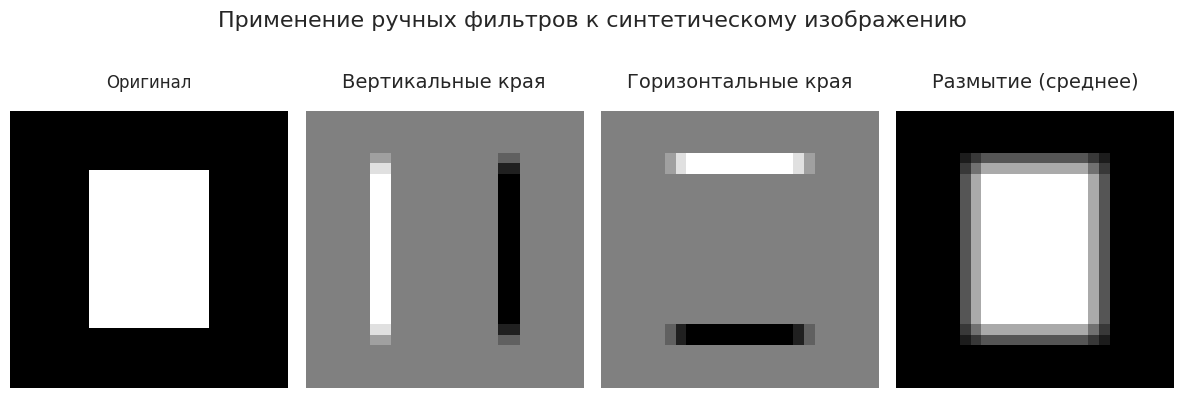

In [5]:
# Задача 4. Визуализация фильтров и карт признаков

# Синтетическое изображение: прямоугольник на черном фоне
img = np.zeros((28, 28), dtype=np.float32)
img[6:22, 8:20] = 1
img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # (1, 1, 28, 28)

# Фильтры 3x3
filters = {
    "Вертикальные края":   torch.tensor([[[[ -1,   0,   1],
                                           [ -2,   0,   2],
                                           [ -1,   0,   1]]]], dtype=torch.float32),
    "Горизонтальные края": torch.tensor([[[[ -1,  -2,  -1],
                                           [  0,   0,   0],
                                           [  1,   2,   1]]]], dtype=torch.float32),
    "Размытие (среднее)":  torch.tensor([[[[1/9, 1/9, 1/9],
                                           [1/9, 1/9, 1/9],
                                           [1/9, 1/9, 1/9]]]], dtype=torch.float32),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Оригинал", size=12, y=1.05)
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], filters.items()):
    out = F.conv2d(img_tensor, kernel)
    out_np = out.squeeze().numpy()
    ax.imshow(out_np, cmap="gray")
    ax.set_title(name, y=1.05)
    ax.axis("off")

plt.suptitle(
    "Применение ручных фильтров к синтетическому изображению",
    size=16,
    y=1.05
)
plt.tight_layout(); plt.show()

> Заметка к Задаче 4  
- __Вертикальные края__ - фильтр Собеля для обнаружения вертикальных перепадов яркости. Он реагирует на изменения слева направо  
- __Горизонтальные края__ - фильтр Собеля для обнаружения горизонтальных перепадов (сверху вниз)  
- __Размытие (среднее)__ - ядро усреднения 3×3, которое сглаживает изображение, удаляя высокочастотные детали  

изменение знака в `img[6:22, 8:20] = -0.5` приведет к инверсии цветов

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Комбинирование концепций: обучение CNN, абляционные эксперименты.

## Задача 5. Классификация FashionMNIST

### Постановка задачи

Обучите CNN-классификатор на датасете FashionMNIST.

### Архитектура
```
Conv2d(1,32,3,p=1)->ReLU->MaxPool(2)
->Conv2d(32,64,3,p=1)->ReLU->MaxPool(2)
->Flatten->Linear(64*7*7,128)->ReLU->Linear(128,10)
```

### Задача
1. Загрузите FashionMNIST, разделите train на train/val (50000/10000).
2. Обучите модель (10 эпох, Adam, lr=0.001, batch_size=64).
3. Постройте кривые обучения (loss, accuracy).
4. Выведите accuracy на тесте и confusion matrix.


Классы (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train: 50000, Val: 10000, Test: 10000
Эпоха  1/10  train_loss=0.4326  val_loss=0.3394  val_acc=0.8791
Эпоха  2/10  train_loss=0.2790  val_loss=0.2679  val_acc=0.9010
Эпоха  3/10  train_loss=0.2292  val_loss=0.2486  val_acc=0.9073
Эпоха  4/10  train_loss=0.1968  val_loss=0.2381  val_acc=0.9147
Эпоха  5/10  train_loss=0.1698  val_loss=0.2256  val_acc=0.9188
Эпоха  6/10  train_loss=0.1465  val_loss=0.2151  val_acc=0.9261
Эпоха  7/10  train_loss=0.1233  val_loss=0.2172  val_acc=0.9251
Эпоха  8/10  train_loss=0.1035  val_loss=0.2366  val_acc=0.9260
Эпоха  9/10  train_loss=0.0856  val_loss=0.2659  val_acc=0.9176
Эпоха 10/10  train_loss=0.0707  val_loss=0.2567  val_acc=0.9253


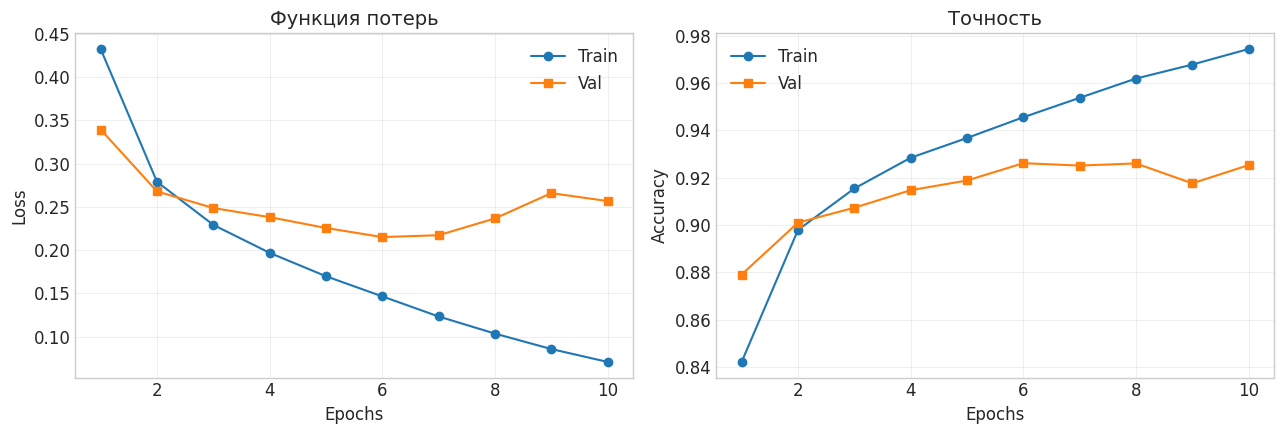


Точность на тесте: 0.9163


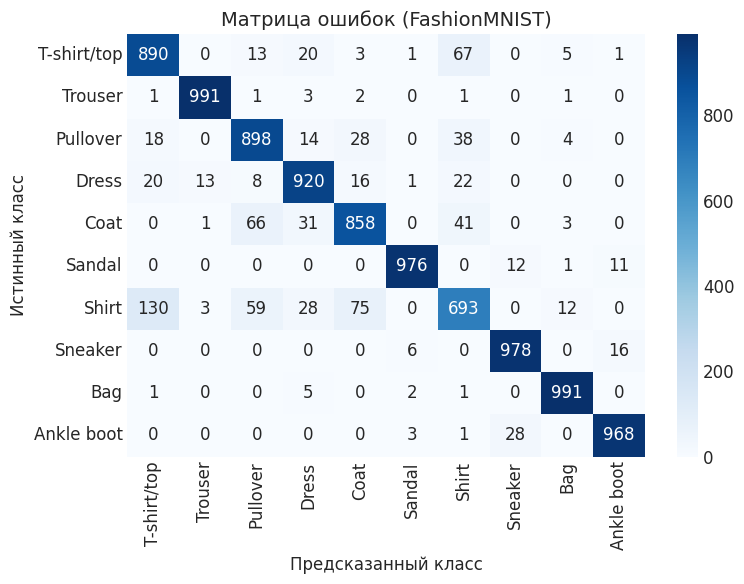

In [6]:
# Задача 5. Классификация FashionMNIST

np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Данные ---
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])

train_full = datasets.FashionMNIST(
    root="./data", train=True,  download=True, transform=transform
)
test_ds = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# TODO: Разбейте train_full на train и val (50000/10000) +
train, val = torch.utils.data.random_split(train_full, [50000, 10000],
                                           generator=torch.Generator().manual_seed(SEED))

print(f"Классы ({len(train_full.classes)}):", train_full.classes)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test_ds)}")

# TODO: Создайте DataLoaders + 
train_loader, val_loader, test_loader = (
    DataLoader(train, batch_size=64, shuffle=True),
    DataLoader(val, batch_size=64),
    DataLoader(test_ds,  batch_size=64)
)

# --- Модель ---
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model = FashionCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Обучение ---
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   [],}

for epoch in range(10):
    # Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)
    train_loss /= train_total
    train_acc = train_correct / train_total

    # Val
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():  # torch без вычисления градиентов и их хранения
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)
    val_loss /= val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch + 1:2d}/10  " + 
          f"train_loss={train_loss:.4f}  " + 
          f"val_loss={val_loss:.4f}  " + 
          f"val_acc={val_acc:.4f}")

# --- Графики ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_range = range(1, 10 + 1)

axes[0].set_title("Функция потерь")
axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val", marker="s")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epochs")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Точность")
axes[1].plot(epochs_range, history["train_acc"], label="Train", marker="o")
axes[1].plot(epochs_range, history["val_acc"],   label="Val", marker="s")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# --- Тест ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_acc = accuracy_score(all_labels, all_preds)

print()
print(f"Точность на тесте: {test_acc:.4f}")

# Confusion matrix
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Предсказанный класс"); plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (FashionMNIST)")
plt.tight_layout(); plt.show()

> Заметка к Задаче 5  
- с увеличением эпох ошибка начала расти, а точность падать. Связано это с тем, что шум в сверточных слоях начал увеличиваться(?). __Основной вывод:__ главное во время остановиться, чтобы не только получить желаемое, но и не сгенерить ерундаций

---

## Задача 6. MaxPool vs Strided Conv (абляция)

### Постановка задачи

Сравните два способа уменьшения пространственного разрешения:
MaxPool2d(2) и Conv2d с stride=2.

### Задача
1. Реализуйте две модели с одинаковой структурой, но разным downsampling.
2. Обучите обе на FashionMNIST (5 эпох).
3. Сравните: число параметров, test accuracy.
4. Постройте график accuracy обеих моделей.


--- Модель A: MaxPool ---
  MaxPool эпоха 1/5  val_acc=0.8791
  MaxPool эпоха 2/5  val_acc=0.9010
  MaxPool эпоха 3/5  val_acc=0.9073
  MaxPool эпоха 4/5  val_acc=0.9147
  MaxPool эпоха 5/5  val_acc=0.9188

--- Модель B: Strided Conv ---
  StridedConv эпоха 1/5  val_acc=0.8745
  StridedConv эпоха 2/5  val_acc=0.8871
  StridedConv эпоха 3/5  val_acc=0.9048
  StridedConv эпоха 4/5  val_acc=0.8967
  StridedConv эпоха 5/5  val_acc=0.9068

Параметры  MaxPool:        421,642
Параметры  StridedConv:    421,642
Accuracy   MaxPool:     0.9141
Accuracy   StridedConv: 0.9065


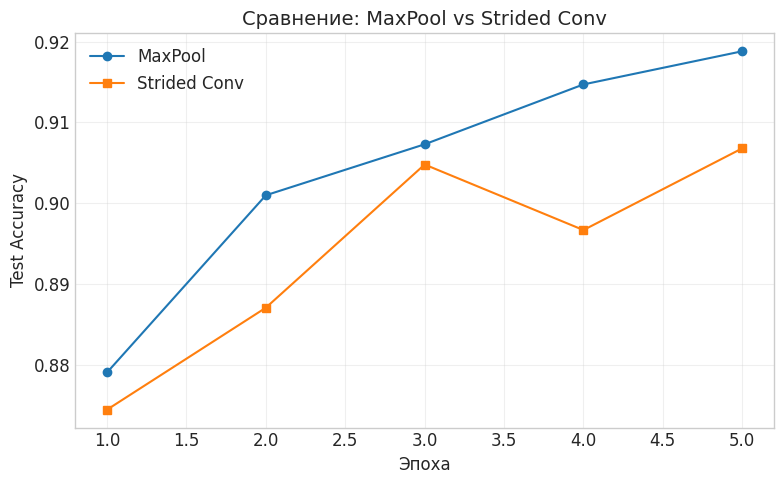

In [7]:
# Задача 6. MaxPool vs Strided Conv

np.random.seed(SEED)
torch.manual_seed(SEED)

class CNN_MaxPool(nn.Module):
    def __init__(self):
        super(CNN_MaxPool, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_StridedConv(nn.Module):
    def __init__(self):
        super(CNN_StridedConv, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

def train_and_eval(model, name, epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    val_accs = []
    for epoch in range(5):
        # Train
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
        
        # Valid
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                _, preds = torch.max(outputs, 1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = correct / total
        val_accs.append(acc)
        print(f"  {name} эпоха {epoch + 1}/{epochs}  val_acc={acc:.4f}")
    return val_accs

print("--- Модель A: MaxPool ---")
m_a = CNN_MaxPool()
accs_a = train_and_eval(m_a, "MaxPool", 5)
p_a = sum(p.numel() for p in m_a.parameters())

print("\n--- Модель B: Strided Conv ---")
m_b = CNN_StridedConv()
accs_b = train_and_eval(m_b, "StridedConv", 5)
p_b = sum(p.numel() for p in m_b.parameters())

# --- Тестовая точность ---
def test_accuracy(model):
    model = model.to(device)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

print()
print(f"Параметры  MaxPool:        {p_a:,}")
print(f"Параметры  StridedConv:    {p_b:,}")
print(f"Accuracy   MaxPool:     {test_accuracy(m_a):.4f}")
print(f"Accuracy   StridedConv: {test_accuracy(m_b):.4f}")

# --- Графики ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), accs_a, marker="o", label="MaxPool")
plt.plot(range(1, 6), accs_b, marker="s", label="Strided Conv")
plt.xlabel("Эпоха")
plt.ylabel("Test Accuracy")
plt.title("Сравнение: MaxPool vs Strided Conv")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Задача 7. Эксперимент с padding: same vs valid

### Постановка задачи

Сравните влияние padding на качество классификации и размер карт признаков.

### Задача
1. Модель A: padding=1 (same) во всех свертках.
2. Модель B: padding=0 (valid).
3. Обучите обе на FashionMNIST (5 эпох).
4. Сравните размеры промежуточных тензоров и accuracy.


In [8]:
# Задача 7. Padding same vs valid

np.random.seed(SEED)
torch.manual_seed(SEED)

class CNN_Same(nn.Module):
    def __init__(self):
        super(CNN_Same, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # могу еще padding="same"
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # могу еще padding="same"
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_Valid(nn.Module):
    def __init__(self):
        super(CNN_Valid, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=0)  # могу еще padding="valid"
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0)  # могу еще padding="valid"
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# --- Проверка размерностей ---
x_test = torch.randn(1, 1, 28, 28)
m_same = CNN_Same()
m_valid = CNN_Valid()

with torch.no_grad():
    out_same1 = m_same.conv1(x_test)
    out_same1_pool = m_same.pool1(m_same.relu1(out_same1))

    out_same2 = m_same.conv2(out_same1_pool)
    out_same2_pool = m_same.pool2(m_same.relu2(out_same2))

    out_valid1 = m_valid.conv1(x_test)
    out_valid1_pool = m_valid.pool1(m_valid.relu1(out_valid1))

    out_valid2 = m_valid.conv2(out_valid1_pool)
    out_valid2_pool = m_valid.pool2(m_valid.relu2(out_valid2))

print("Размерности карт признаков:")
print(f"  Same (p=1):  Conv1->{out_same1_pool.shape}  Conv2->{out_same2_pool.shape}")
print(f"  Valid (p=0): Conv1->{out_valid1_pool.shape}  Conv2->{out_valid2_pool.shape}")

print("\n--- Модель Same (padding=1) ---")
accs_same = train_and_eval(m_same, "Same", 5)

print("\n--- Модель Valid (padding=0) ---")
accs_valid = train_and_eval(m_valid, "Valid", 5)

print()
print(f"Accuracy  Same:  {test_accuracy(m_same):.4f}")
print(f"Accuracy  Valid: {test_accuracy(m_valid):.4f}")
print()
print("Вывод: padding=0 уменьшает размер карт признаков, что приводит \n" +
      "к потере информации на краях изображения. Для глубоких сетей это критично.")

Размерности карт признаков:
  Same (p=1):  Conv1->torch.Size([1, 32, 14, 14])  Conv2->torch.Size([1, 64, 7, 7])
  Valid (p=0): Conv1->torch.Size([1, 32, 13, 13])  Conv2->torch.Size([1, 64, 5, 5])

--- Модель Same (padding=1) ---
  Same эпоха 1/5  val_acc=0.8911
  Same эпоха 2/5  val_acc=0.9004
  Same эпоха 3/5  val_acc=0.9090
  Same эпоха 4/5  val_acc=0.9073
  Same эпоха 5/5  val_acc=0.9127

--- Модель Valid (padding=0) ---
  Valid эпоха 1/5  val_acc=0.8712
  Valid эпоха 2/5  val_acc=0.8891
  Valid эпоха 3/5  val_acc=0.8961
  Valid эпоха 4/5  val_acc=0.9027
  Valid эпоха 5/5  val_acc=0.9036

Accuracy  Same:  0.9049
Accuracy  Valid: 0.9012

Вывод: padding=0 уменьшает размер карт признаков, что приводит 
к потере информации на краях изображения. Для глубоких сетей это критично.


---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Детекция и сегментация на синтетических данных.

## Задача 8. Toy Detection: регрессия Bounding Box

### Постановка задачи

Генерируются синтетические 64x64 изображения с одним прямоугольником
в случайной позиции. Модель предсказывает координаты Bounding Box.

### Задача
1. Сгенерируйте 1000 train и 200 test изображений.
2. Реализуйте CNN для регрессии: выход — 4 числа (x, y, w, h), нормализованных в [0, 1].
3. Loss: MSE.  Метрика: IoU.
4. Обучите 30 эпох.
5. Визуализируйте 6 примеров с истинным и предсказанным bbox.


In [9]:
# Задача 8. Toy Detection

torch.manual_seed(SEED)
np.random.seed(SEED)

def generate_detection_data(n, img_size=64):
    """Генерация изображений с одним прямоугольником и bbox-метками."""
    assert "ваш код здесь"

X_train, Y_train = generate_detection_data(1000)
X_test,  Y_test  = generate_detection_data(200)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_det_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)

# --- IoU ---
def compute_iou(pred, target):
    """Вычисляет IoU для bbox в формате (cx, cy, w, h), нормализованных."""
    # Перевод в (x1, y1, x2, y2)
    assert "ваш код здесь"

# --- Модель ---
class DetectionCNN(nn.Module):
    def __init__(self):
        assert "ваш код здесь"

    def forward(self, x):
        assert "ваш код здесь"

model_det = DetectionCNN().to(device)
optimizer = optim.Adam(model_det.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- Обучение ---
losses = []
# for epoch in range(30):
    # ваш код здесь

# --- Визуализация ---
import matplotlib.patches as patches

model_det.eval()
with torch.no_grad():
    preds_all = model_det(X_test.to(device)).cpu()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# for idx, ax in enumerate(axes.flat):
    # ваш код здесь

axes[0, 0].legend(loc='upper left')
plt.suptitle("Toy Detection: истинный (зелёный) и предсказанный (красный) bbox")
plt.tight_layout(); plt.show()

final_iou = compute_iou(preds_all, Y_test)
print(f"\nСредний IoU на тесте: {final_iou:.4f}")


TypeError: cannot unpack non-iterable NoneType object

---

## Задача 9. Toy Segmentation: мини encoder-decoder

### Постановка задачи

Реализуйте сеть типа encoder-decoder со Skip Connections для бинарной
сегментации синтетических изображений.

### Задача
1. Сгенерируйте 800 train и 200 test пар (изображение, маска) с кругами/прямоугольниками.
2. Encoder: 3 уровня (Conv+ReLU+MaxPool).
3. Decoder: 3 уровня (ConvTranspose + Skip Connection + Conv+ReLU).
4. Loss: BCEWithLogitsLoss.  Метрики: IoU, Dice.
5. Обучите 30 эпох.
6. Визуализируйте 6 примеров: вход, истинная маска, предсказанная маска.


In [ ]:
# Задача 9. Toy Segmentation: мини encoder-decoder

torch.manual_seed(SEED)
np.random.seed(SEED)

def generate_segmentation_data(n, img_size=64):
    """Генерация изображений с фигурами и бинарных масок."""
    images, masks = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        mask = np.zeros((img_size, img_size), dtype=np.float32)
        # Случайный круг или прямоугольник
        if np.random.rand() > 0.5:
            # Круг
            cx, cy = np.random.randint(15, img_size - 15, size=2)
            r = np.random.randint(5, 15)
            yy, xx = np.ogrid[:img_size, :img_size]
            circle = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[circle] = 1.0
            mask[circle] = 1.0
        else:
            # Прямоугольник
            w = np.random.randint(10, 30)
            h = np.random.randint(10, 30)
            x = np.random.randint(0, img_size - w)
            y = np.random.randint(0, img_size - h)
            img[y:y+h, x:x+w] = 1.0
            mask[y:y+h, x:x+w] = 1.0
        # Добавим немного шума к изображению
        img += 0.1 * np.random.randn(img_size, img_size).astype(np.float32)
        images.append(img)
        masks.append(mask)
    X = torch.tensor(np.array(images)).unsqueeze(1)
    Y = torch.tensor(np.array(masks)).unsqueeze(1)
    return X, Y

X_tr_seg, Y_tr_seg = generate_segmentation_data(800)
X_te_seg, Y_te_seg = generate_segmentation_data(200)
print(f"Train: {X_tr_seg.shape}, Test: {X_te_seg.shape}")

seg_train_loader = DataLoader(TensorDataset(X_tr_seg, Y_tr_seg), batch_size=16, shuffle=True)

# --- Метрики ---
def iou_score(pred_mask, true_mask, threshold=0.5):
    assert "ваш код здесь"

def dice_score(pred_mask, true_mask, threshold=0.5):
    assert "ваш код здесь"

# --- Мини U-Net ---
class MiniUNet(nn.Module):
    def __init__(self):
        assert "ваш код здесь"

    def forward(self, x):
        assert "ваш код здесь"

model_seg = MiniUNet().to(device)
optimizer = optim.Adam(model_seg.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# --- Обучение ---
seg_losses = []
# for epoch in range(30):
    # ваш код здесь

# --- Визуализация ---
model_seg.eval()
with torch.no_grad():
    pred_masks = torch.sigmoid(model_seg(X_te_seg.to(device))).cpu()


fig, axes = plt.subplots(3, 6, figsize=(16, 8))
titles_row = ["Вход", "Истинная маска", "Предсказанная маска"]

# for col in range(6):
    # ваш код здесь

for row, title in enumerate(titles_row):
    axes[row, 0].set_ylabel(title, fontsize=11, rotation=90, labelpad=40)

plt.suptitle("Toy Segmentation: результаты мини U-Net")
plt.tight_layout(); plt.show()

# Средние метрики
ious  = [iou_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
dices = [dice_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
print(f"\nСредний IoU  на тесте: {np.mean(ious):.4f}")
print(f"Средний Dice на тесте: {np.mean(dices):.4f}")
